# Online Shopping Purchase Prediction

**Challenge:** Predict whether a website visitor's session will end in a purchase (`Revenue`), using the UCI *Online Shoppers Purchasing Intention* dataset.

This notebook covers:
1. Data exploration & preprocessing
2. Exploratory Data Analysis (EDA) with key insights
3. Visualizations of important patterns
4. Model training & evaluation
5. Discussion of approach and observations

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (7, 4.5)
pd.set_option("display.max_columns", 20)

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
print("Shape:", df.shape)
df.head()

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

## 2. Explore & Preprocess the Dataset

The dataset has **12,330 sessions** and **18 columns** (10 numeric behavioural features, 6 categorical/technical
identifiers, and the target `Revenue`). First, check data quality: missing values, duplicates, and data types.

In [4]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values

Duplicate rows: 125

In [5]:
# Drop exact duplicate sessions (125 rows) - they add no information and can bias the model
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (12205, 18)


**Preprocessing steps applied:**
- Dropped 125 duplicate rows.
- Converted the boolean columns (`Weekend`, `Revenue`) to integers (0/1).
- Label-encoded `Month` (ordinal-ish, 10 categories).
- One-hot encoded `VisitorType` (`New_Visitor`, `Returning_Visitor`, `Other`).
- Standardized numeric features (only needed for the distance/gradient-based model, Logistic Regression — tree-based
  Random Forest is scale-invariant so it is trained on the unscaled version).

In [6]:
df_model = df.copy()
df_model["Weekend"] = df_model["Weekend"].astype(int)
df_model["Revenue"] = df_model["Revenue"].astype(int)

month_encoder = LabelEncoder()
df_model["Month"] = month_encoder.fit_transform(df_model["Month"])

df_model = pd.get_dummies(df_model, columns=["VisitorType"], drop_first=True)

df_model.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,0,0,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,0,0,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,0,0,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,0,0,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,1,0,False,True


## 3. Exploratory Data Analysis (EDA)

### Insight 1 — The target classes are imbalanced

Revenue
False    84.37
True     15.63
Name: proportion, dtype: float64

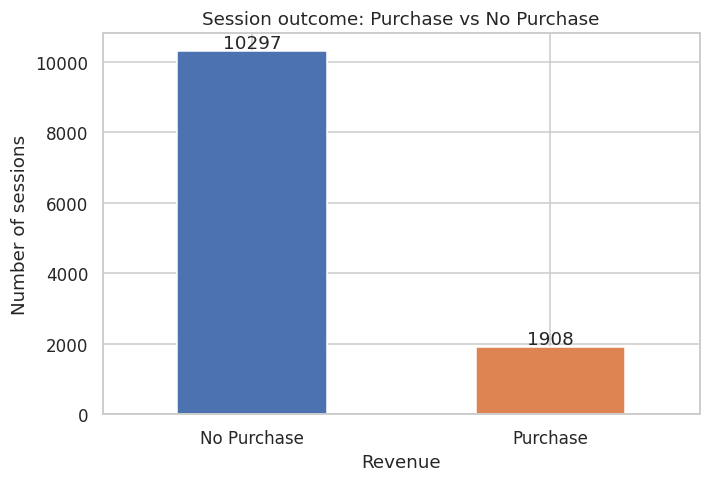

In [7]:
revenue_counts = df["Revenue"].value_counts(normalize=True) * 100
print(revenue_counts.round(2))

fig, ax = plt.subplots()
df["Revenue"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_xticklabels(["No Purchase", "Purchase"], rotation=0)
ax.set_ylabel("Number of sessions")
ax.set_title("Session outcome: Purchase vs No Purchase")
for i, v in enumerate(df["Revenue"].value_counts()):
    ax.text(i, v + 100, str(v), ha="center")
plt.show()

Only **15.5% of sessions** end in a purchase — the classes are notably imbalanced. This matters for modeling:
plain accuracy will look good even for a model that mostly predicts "no purchase", so precision/recall/F1/ROC-AUC
matter more than accuracy alone, and `class_weight="balanced"` is worth using during training.

### Insight 2 — Purchase rate varies strongly by month (seasonality)

Month
Feb      1.66
Mar     10.32
May     10.96
June    10.18
Jul     15.28
Aug     17.55
Sep     19.20
Oct     20.95
Nov     25.49
Dec     12.66
Name: Revenue, dtype: float64

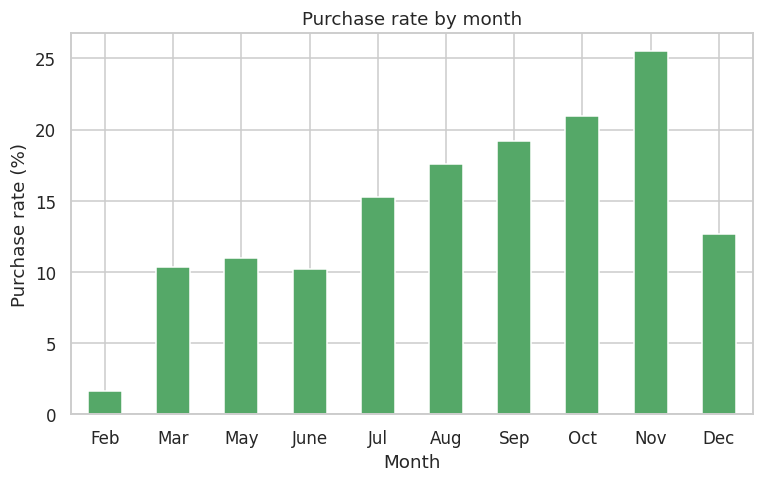

In [8]:
month_order = ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]
month_rate = df.groupby("Month")["Revenue"].mean().reindex(month_order) * 100

fig, ax = plt.subplots(figsize=(8,4.5))
month_rate.plot(kind="bar", color="#55A868", ax=ax)
ax.set_ylabel("Purchase rate (%)")
ax.set_title("Purchase rate by month")
plt.xticks(rotation=0)
plt.show()

print(month_rate.round(2))

**November has by far the highest conversion rate (~25.4%)**, consistent with Black Friday / holiday shopping season,
while **February is the lowest (~1.6%)**. Interestingly, the dataset has no January or April sessions at all. This
suggests a seasonal/promotional feature (or simply the month itself) is a genuinely useful predictor, not noise.

### Insight 3 — New visitors convert at a higher rate than returning visitors

                    mean  count
VisitorType                    
New_Visitor        24.93   1693
Other              19.75     81
Returning_Visitor  14.09  10431

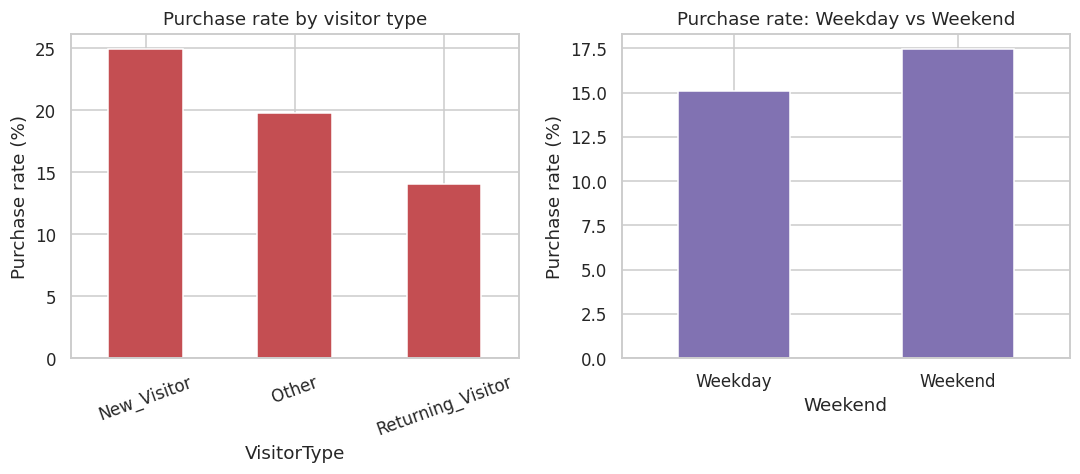

In [9]:
visitor_rate = df.groupby("VisitorType")["Revenue"].agg(["mean","count"])
visitor_rate["mean"] = (visitor_rate["mean"]*100).round(2)
print(visitor_rate)

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
(df.groupby("VisitorType")["Revenue"].mean()*100).plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_ylabel("Purchase rate (%)")
axes[0].set_title("Purchase rate by visitor type")
axes[0].tick_params(axis='x', rotation=20)

(df.groupby("Weekend")["Revenue"].mean()*100).plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_xticklabels(["Weekday","Weekend"], rotation=0)
axes[1].set_ylabel("Purchase rate (%)")
axes[1].set_title("Purchase rate: Weekday vs Weekend")
plt.tight_layout()
plt.show()

**New visitors** convert at **24.9%**, almost double the rate of **returning visitors (13.9%)** — despite returning
visitors making up 86% of all traffic. Sessions on the **weekend** also convert slightly better than weekdays
(17.4% vs 14.9%), a smaller but still noticeable effect.

### Insight 4 — `PageValues` is the single strongest signal of purchase intent

              mean        50%         max
Revenue                                  
False     1.999985   0.000000  246.758590
True     27.264518  16.758134  361.763742

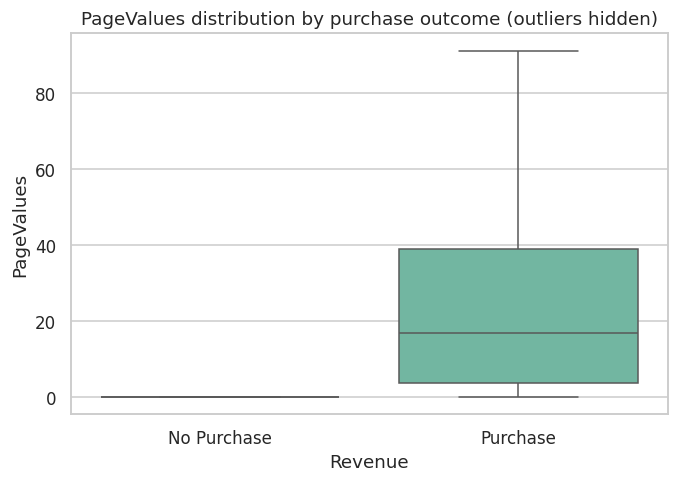

In [10]:
print(df.groupby("Revenue")["PageValues"].describe()[["mean","50%","max"]])

fig, ax = plt.subplots()
sns.boxplot(data=df, x="Revenue", y="PageValues", showfliers=False, ax=ax)
ax.set_xticklabels(["No Purchase","Purchase"])
ax.set_title("PageValues distribution by purchase outcome (outliers hidden)")
plt.show()

Sessions that end in a purchase have an **average `PageValues` of 27.3**, versus just **1.98** for sessions that
don't — a huge gap. `PageValues` (Google Analytics' estimate of a page's contribution to revenue) looks like it is
almost a proxy for purchase intent itself.

### Insight 5 — Bounce/Exit rates are negatively correlated with purchases; overall correlation picture

,Revenue
PageValues,0.491894
ProductRelated,0.156042
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
Weekend,0.027729
Browser,0.024052
TrafficType,-0.005618


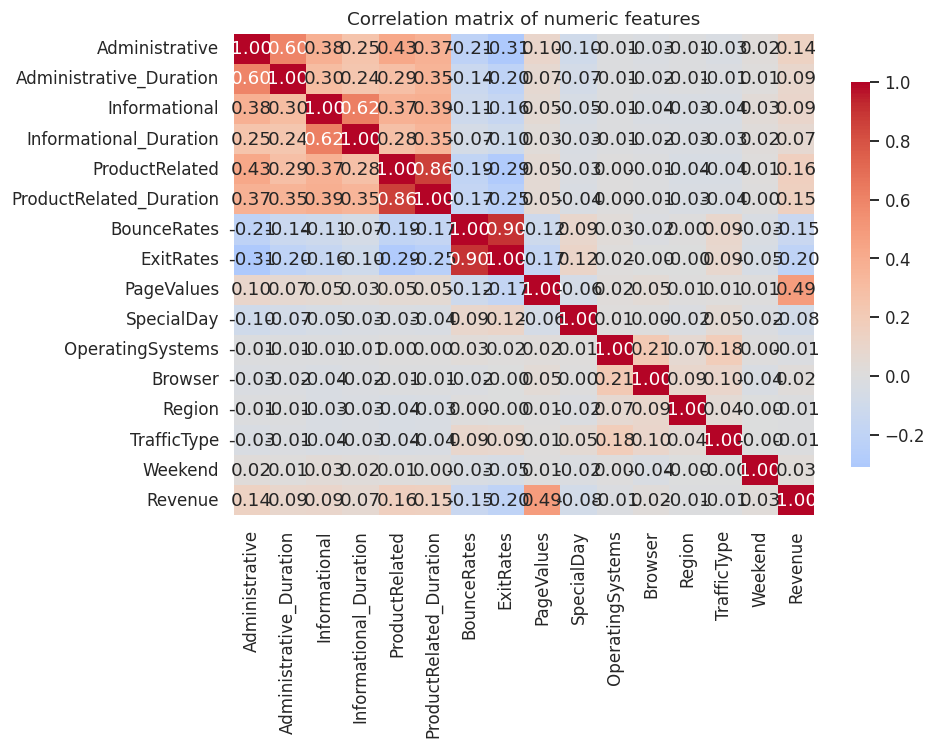

In [11]:
numeric_cols = df.select_dtypes(include=["int64","float64","bool"]).columns
corr = df[numeric_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()

corr["Revenue"].drop("Revenue").sort_values(ascending=False)

`PageValues` (**+0.49**) is by far the strongest correlate of `Revenue`. `ExitRates` (**-0.21**) and `BounceRates`
(**-0.15**) are the strongest *negative* correlates — sessions where visitors bounce quickly or exit early are much
less likely to convert, which makes intuitive sense. `ProductRelated` page count/duration and `Administrative`
activity show smaller positive correlations. Technical fields (`OperatingSystems`, `Browser`, `Region`,
`TrafficType`) show almost no linear relationship with `Revenue`.

## 4. Model Training & Evaluation

**Approach:** This is a binary classification problem with a real class imbalance (84.5% / 15.5%). Two models are
trained and compared:

- **Logistic Regression** — a simple, interpretable linear baseline (features standardized, `class_weight="balanced"`).
- **Random Forest** — a stronger non-linear ensemble that also gives feature importances (unscaled features,
  `class_weight="balanced"`).

Data is split **80/20** with stratification on `Revenue` so both sets keep the same purchase rate.

In [12]:
X = df_model.drop(columns=["Revenue"])
y = df_model["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train purchase rate: %.2f%%  Test purchase rate: %.2f%%" %
      (y_train.mean()*100, y_test.mean()*100))

Train shape: (9764, 18)  Test shape: (2441, 18)
Train purchase rate: 15.63%  Test purchase rate: 15.65%

In [13]:
numeric_features = ["Administrative","Administrative_Duration","Informational","Informational_Duration",
                     "ProductRelated","ProductRelated_Duration","BounceRates","ExitRates",
                     "PageValues","SpecialDay"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

### Model A — Logistic Regression

In [14]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

pred_lr = log_reg.predict(X_test_scaled)
proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, pred_lr, target_names=["No Purchase","Purchase"], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 3))

              precision    recall  f1-score   support

 No Purchase      0.953     0.893     0.922      2059
    Purchase      0.569     0.764     0.653       382

    accuracy                          0.873      2441
   macro avg      0.761     0.829     0.787      2441
weighted avg      0.893     0.873     0.880      2441

ROC-AUC: 0.898

### Model B — Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, target_names=["No Purchase","Purchase"], digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 3))

              precision    recall  f1-score   support

 No Purchase      0.922     0.964     0.943      2059
    Purchase      0.744     0.563     0.641       382

    accuracy                          0.901      2441
   macro avg      0.833     0.763     0.792      2441
weighted avg      0.894     0.901     0.896      2441

ROC-AUC: 0.928

### Comparing the two models

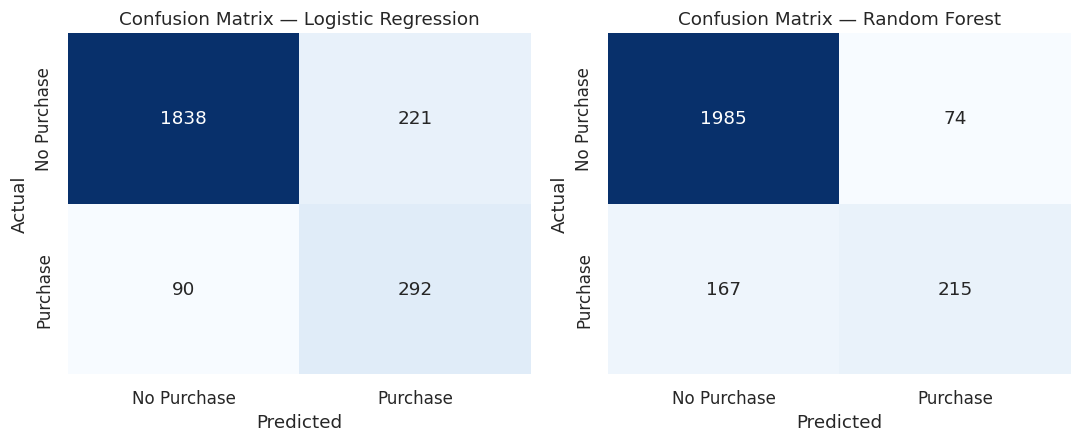

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.2))
for ax, (name, pred) in zip(axes, [("Logistic Regression", pred_lr), ("Random Forest", pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Purchase","Purchase"], yticklabels=["No Purchase","Purchase"], ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

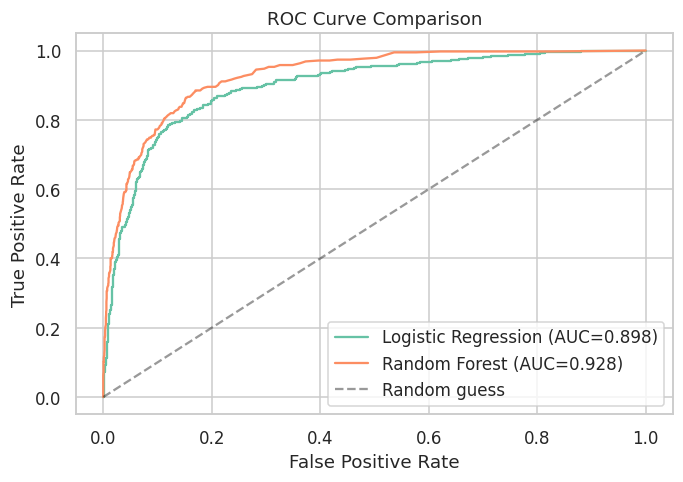

In [17]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

fig, ax = plt.subplots()
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, proba_lr):.3f})")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, proba_rf):.3f})")
ax.plot([0,1],[0,1],"k--", alpha=0.4, label="Random guess")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

### Feature importance (Random Forest)

,0
PageValues,0.392531
ExitRates,0.097979
ProductRelated_Duration,0.092077
ProductRelated,0.067147
Month,0.062285
BounceRates,0.054191
Administrative_Duration,0.048743
Administrative,0.039403
TrafficType,0.027731
Region,0.026340


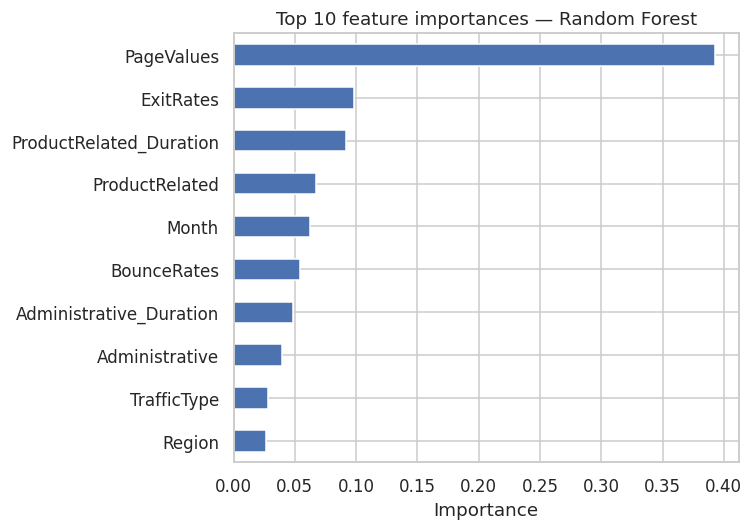

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
importances.head(10).sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Top 10 feature importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)

## 5. Approach & Observations — Summary

**Approach.** After confirming there were no missing values (but 125 exact duplicate rows, which were dropped),
categorical fields (`Month`, `VisitorType`) were encoded and boolean fields converted to integers. Given the
84.5/15.5 class imbalance, both models were trained with `class_weight="balanced"`, and evaluation focused on
precision/recall/F1/ROC-AUC for the minority ("Purchase") class rather than raw accuracy.

**Key observations:**
- **`PageValues` is the dominant predictor** by a wide margin (correlation +0.49, ~39% of Random Forest's total
  feature importance) — sessions that reach high-value pages convert far more often.
- **Seasonality matters**: November sessions convert at ~25%, over 15x the rate of February (~1.6%).
- **New visitors convert almost 2x more often than returning visitors** (24.9% vs 13.9%), even though returning
  visitors are the large majority of traffic — worth noting for marketing/retention strategy.
- **Bounce/Exit rates are inversely related to conversion**, an intuitive but useful confirmation.
- **Random Forest outperforms Logistic Regression overall** (ROC-AUC ≈ 0.93 vs ≈ 0.90, accuracy ≈ 90% vs ≈ 87%) and
  gives higher *precision* on the Purchase class — useful if the business wants to act only on high-confidence
  predictions (e.g. targeted offers). **Logistic Regression has higher *recall*** on the Purchase class, so it would
  catch more true purchasers at the cost of more false alarms — useful if the goal is to flag every potential
  customer (e.g. broad remarketing) instead. Which model to prefer depends on that business trade-off, not accuracy
  alone.

**Possible next steps:** try gradient boosting (XGBoost/LightGBM), address the imbalance with SMOTE instead of just
class weighting, and tune the decision threshold to hit a target precision/recall trade-off.